In [35]:
import sqlite3

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D

In [36]:
df = pl.read_parquet("out/*.parquet")

df

iterations,invalidation_method_compress,invalidation_method_decompress,page_number,compressed_size,uncompressed_size,compression_time,decompression_time,version,trace,alg
i64,i64,i64,i64,i64,i64,i64,i64,i32,str,str
20,0,0,1,664,4096,16201,14370,1,"""login""","""WK64"""
20,0,0,2,1088,4096,35392,27469,1,"""login""","""WK64"""
20,0,0,3,704,4096,23065,21167,1,"""login""","""WK64"""
20,0,0,4,3896,4096,197169,138909,1,"""login""","""WK64"""
20,0,0,5,3848,4096,120711,81745,1,"""login""","""WK64"""
…,…,…,…,…,…,…,…,…,…,…
20,1,1,455,1161,4096,22328,8264,1,"""work-small""","""zstd"""
20,1,1,456,939,4096,20642,10220,1,"""work-small""","""zstd"""
20,1,1,457,1553,4096,22473,9337,1,"""work-small""","""zstd"""


<Axes: xlabel='page_number', ylabel='smooth_comptime'>

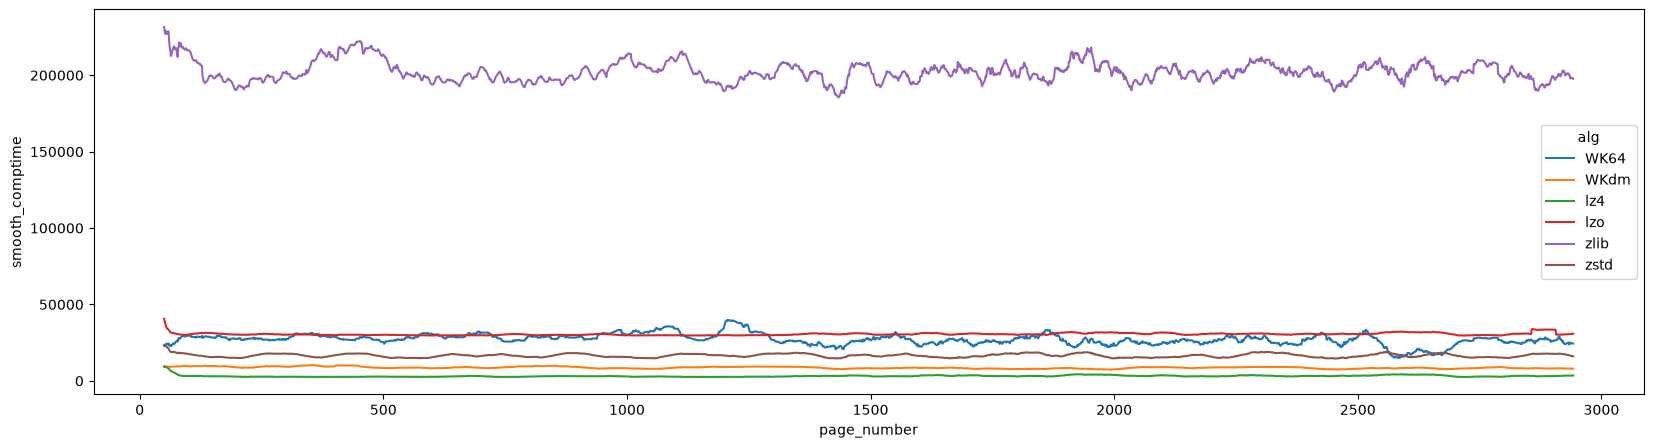

In [37]:
df1 = df.filter(
    pl.col("trace") == "ollama",
    pl.col("invalidation_method_compress") == 0,
    pl.col("invalidation_method_decompress") == 0,
).with_columns(
    pl.col("compression_time")
    .rolling_mean(window_size=50)
    .over("alg")
    .alias("smooth_comptime")
)

plt.figure(figsize=(20,5))
sns.lineplot(
    df1,
    x="page_number",
    y="smooth_comptime",
    hue="alg"
)

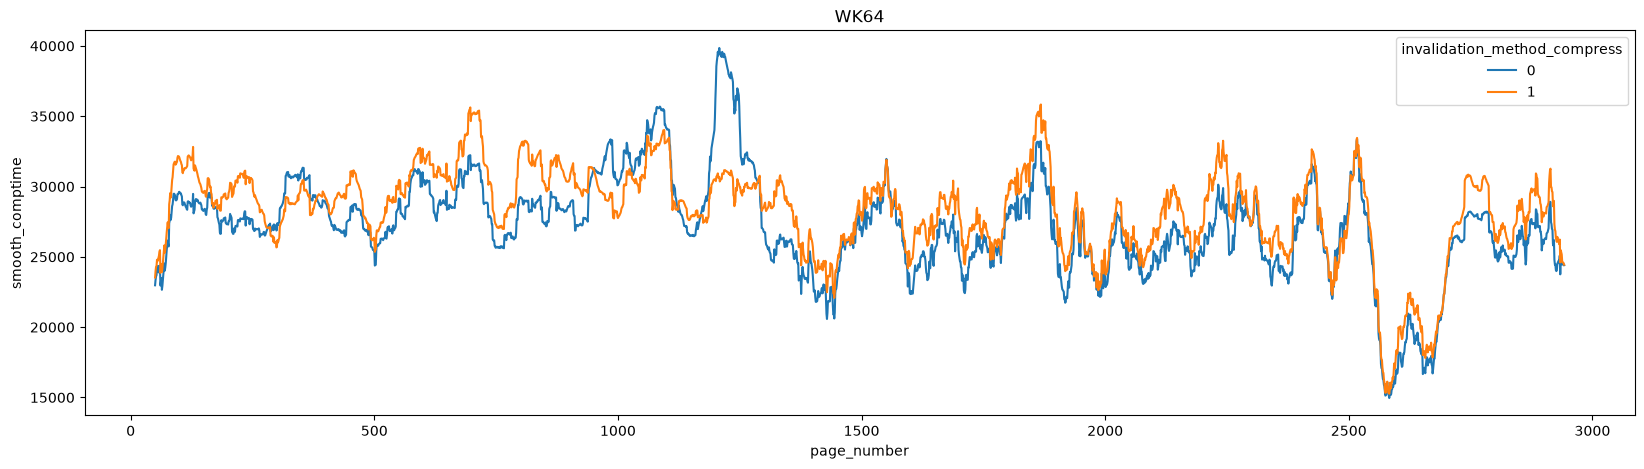

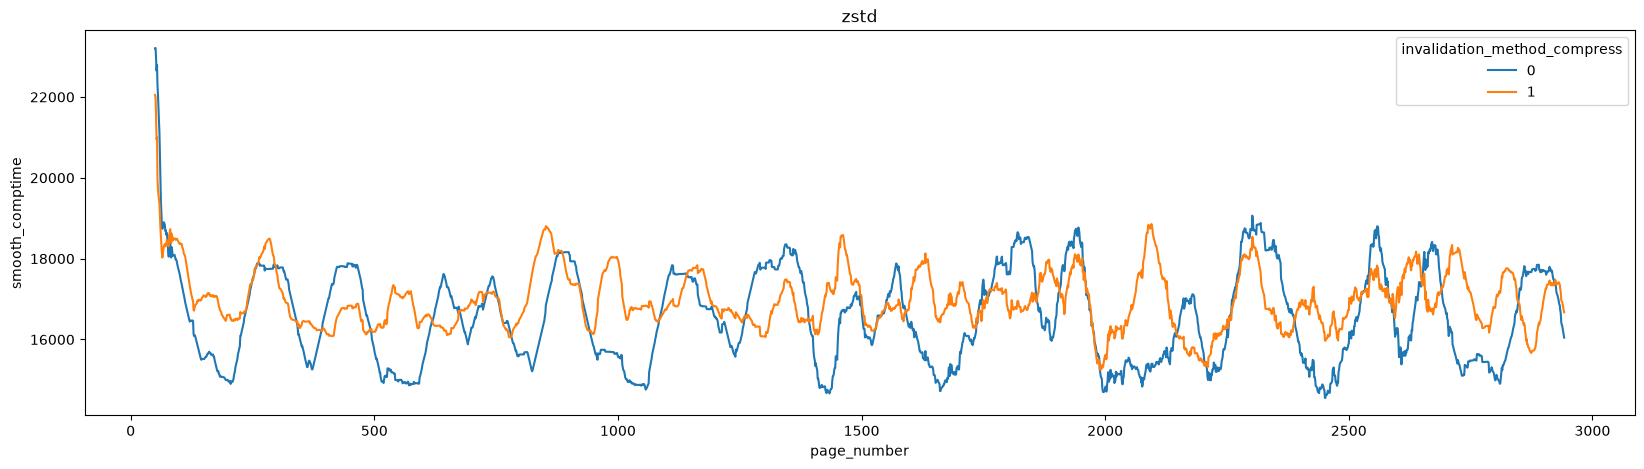

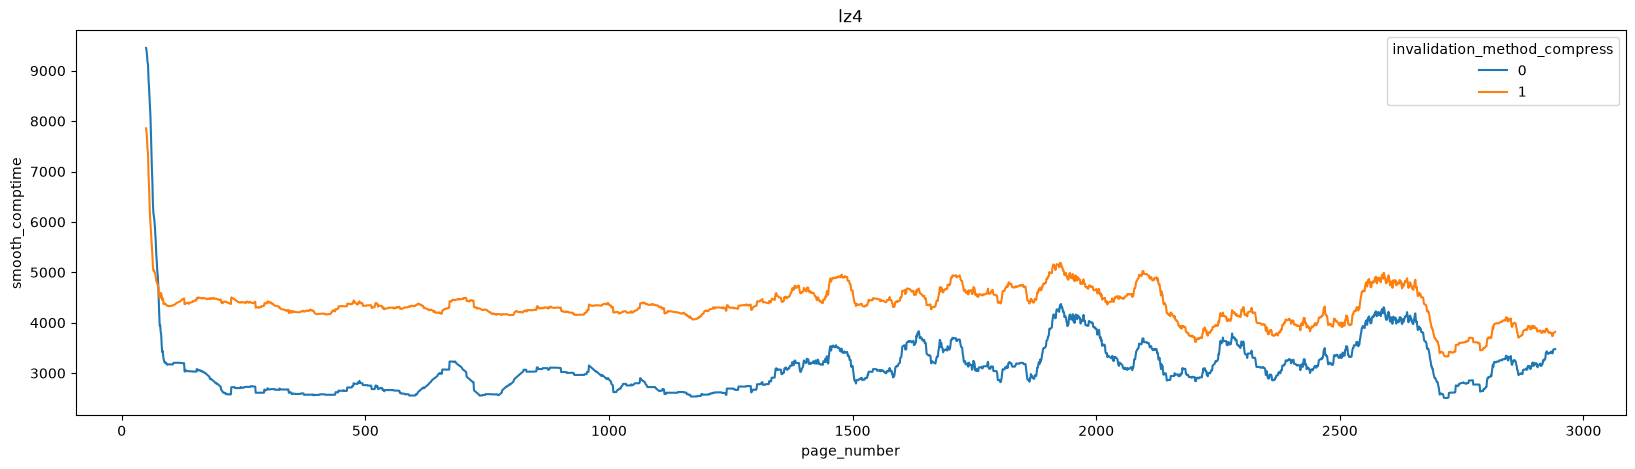

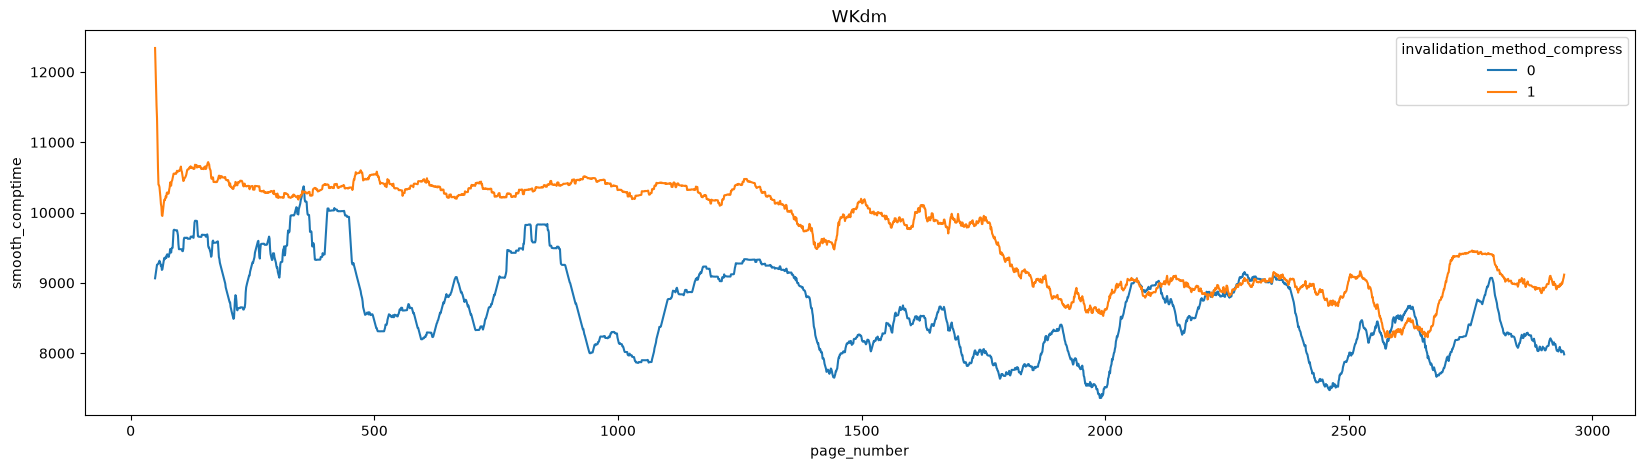

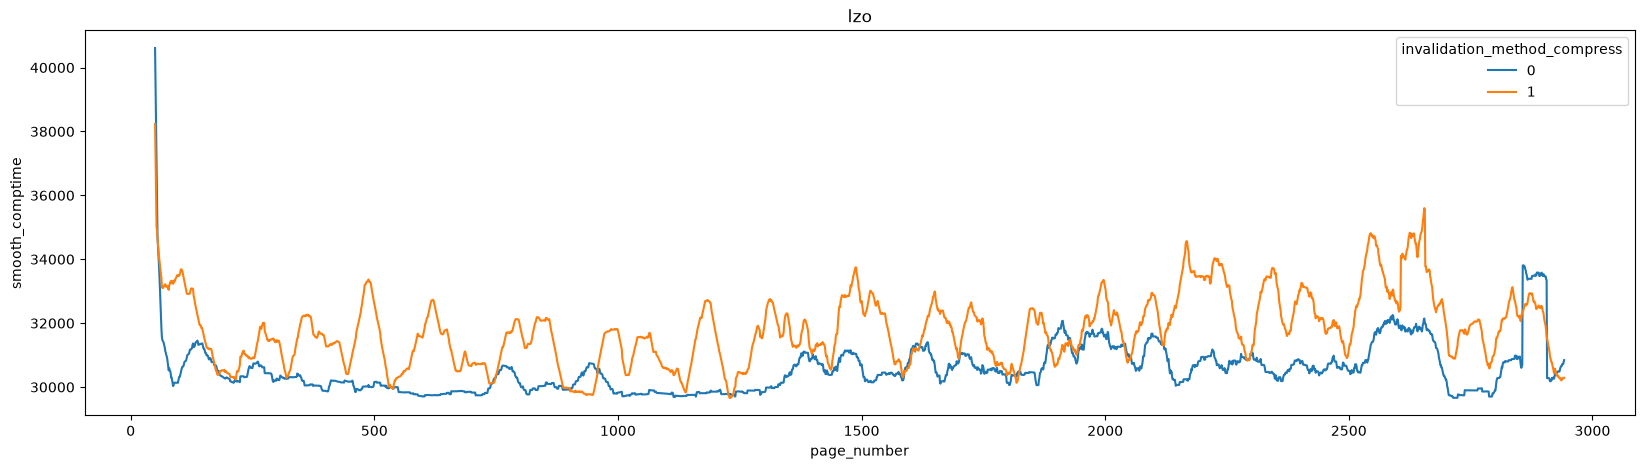

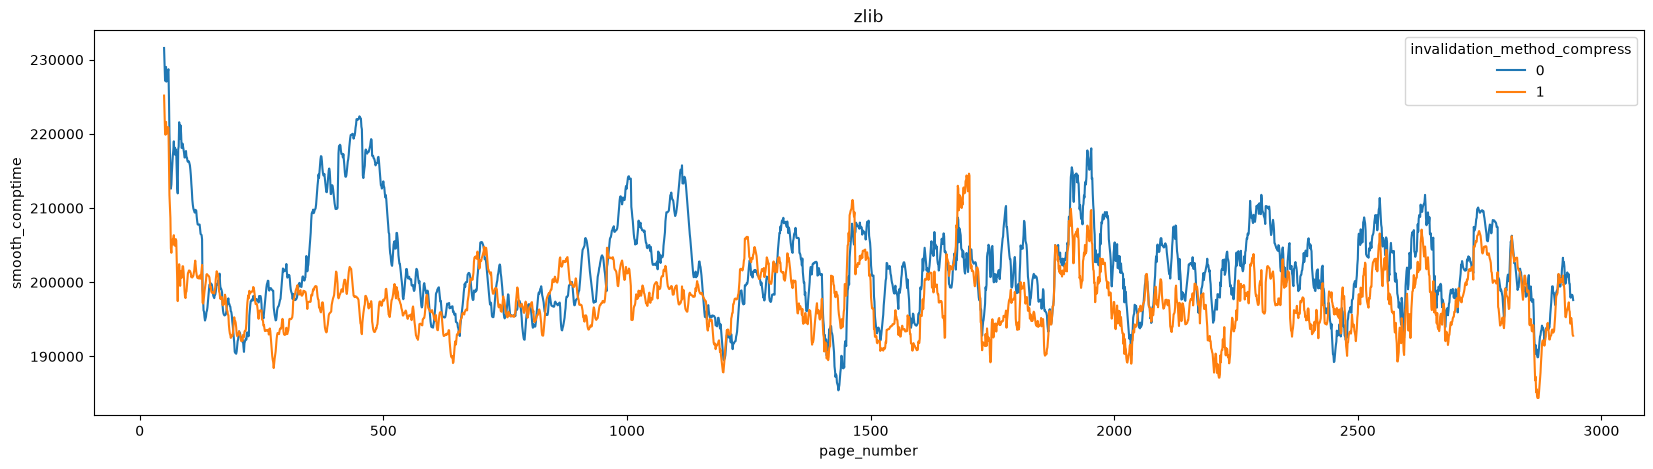

In [38]:
df1 = df.filter(
    pl.col("trace") == "ollama",
    (
        ((pl.col("invalidation_method_compress") == 0) & (pl.col("invalidation_method_decompress") == 0))
        |
        ((pl.col("invalidation_method_compress") == 1) & (pl.col("invalidation_method_decompress") == 1))
    )
).with_columns(
    pl.col("compression_time")
    .rolling_mean(window_size=50)
    .over(["alg", "invalidation_method_compress"])
    .alias("smooth_comptime")
)

for alg in df["alg"].unique().to_list():
    plt.figure(figsize=(20,5))
    ax = sns.lineplot(
        df1.filter(pl.col("alg") == alg),
        x="page_number",
        y="smooth_comptime",
        hue="invalidation_method_compress"
    )
    ax.set_title(f"{alg}")

In [39]:
df1

iterations,invalidation_method_compress,invalidation_method_decompress,page_number,compressed_size,uncompressed_size,compression_time,decompression_time,version,trace,alg,smooth_comptime
i64,i64,i64,i64,i64,i64,i64,i64,i32,str,str,f64
20,0,0,1,152,4096,9888,9008,1,"""ollama""","""WK64""",null
20,0,0,2,424,4096,13803,15588,1,"""ollama""","""WK64""",null
20,0,0,3,800,4096,25042,19908,1,"""ollama""","""WK64""",null
20,0,0,4,224,4096,9403,9863,1,"""ollama""","""WK64""",null
20,0,0,5,1232,4096,32525,36438,1,"""ollama""","""WK64""",null
…,…,…,…,…,…,…,…,…,…,…,…
20,1,1,2938,657,4096,18527,9239,1,"""ollama""","""zstd""",16929.02
20,1,1,2939,4106,4096,15689,1592,1,"""ollama""","""zstd""",16857.68
20,1,1,2940,4106,4096,15640,1657,1,"""ollama""","""zstd""",16786.36


In [40]:
res = (
    df1.drop_nulls(subset=["smooth_comptime"])
    .group_by("alg")
    .agg(
        [
            pl.col("smooth_comptime")
            .filter(pl.col("invalidation_method_compress") == 0)
            .mean()
            .alias("mean_0"),
            pl.col("smooth_comptime")
            .filter(pl.col("invalidation_method_compress") == 1)
            .mean()
            .alias("mean_1"),
        ]
    )
    .with_columns(
        (100 * pl.col("mean_1") / pl.col("mean_0")).alias("pct_1_of_0"),
        ((pl.col("mean_1") - pl.col("mean_0")) / pl.col("mean_0") * 100).alias("pct_change_vs_0"),
    )
)
res

alg,mean_0,mean_1,pct_1_of_0,pct_change_vs_0
str,f64,f64,f64,f64
"""WK64""",27160.782592,28292.470149,104.166624,4.166624
"""zstd""",16562.522247,16982.622952,102.536454,2.536454
"""lz4""",3122.902468,4338.866167,138.936973,38.936973
"""lzo""",30557.754704,31797.317587,104.056459,4.056459
"""WKdm""",8629.562371,9710.211068,112.522636,12.522636
"""zlib""",202157.479806,197772.783049,97.831049,-2.168951
